# Stage 1 — Person Detection Evaluation

Run YOLOv8s person detection against a sample clip and visualise per-frame bounding boxes.

**What this notebook covers:**
- Frame extraction from video at 15 fps via `pipeline.ingest`
- Person detection via `pipeline.detect.PersonDetector` (YOLOv8s)
- Visualising bounding boxes with confidence scores on a frame grid
- Detection statistics (count per frame, confidence distribution)
- Saving results to `PipelineCache` for downstream notebooks

**Estimated run time:** ~2–5 min CPU / ~20 s GPU for a 30 s clip.

In [1]:
import sys
sys.path.insert(0, '..')   # make pipeline/ importable from notebooks/

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Config — edit VIDEO_PATH to point at your clip ───────────────────────────
VIDEO_PATH      = Path('../data/raw_footage/agility_test.mp4')
TARGET_FPS      = 15
MAX_FRAMES      = 60       # None = process entire clip
CONF_THRESHOLD  = 0.40
JOB_ID          = 'notebook-eval-detection'

print(f"Video path: {VIDEO_PATH}  exists={VIDEO_PATH.exists()}")

Video path: ../data/raw_footage/agility_test.mp4  exists=True


In [2]:
from pipeline.ingest import extract_frames

frames, frame_indices, timestamps = [], [], []
for fi, frame, ts in extract_frames(str(VIDEO_PATH), target_fps=TARGET_FPS):
    frames.append(frame)
    frame_indices.append(fi)
    timestamps.append(ts)
    if MAX_FRAMES and len(frames) >= MAX_FRAMES:
        break

print(f"Extracted {len(frames)} frames  "
      f"(covers {timestamps[-1]:.1f}s of footage)  "
      f"resolution {frames[0].shape[1]}×{frames[0].shape[0]}")

Extracted 60 frames  (covers 3.9s of footage)  resolution 832×464


In [3]:
from pipeline.detect import PersonDetector

detector = PersonDetector(conf_threshold=CONF_THRESHOLD)
all_detections = []

for i, frame in enumerate(frames):
    dets = detector.detect(frame)
    for d in dets:
        d.frame_idx = frame_indices[i]
    all_detections.append(dets)
    if i % 10 == 0:
        print(f"  frame {frame_indices[i]:4d}  t={timestamps[i]:.2f}s  n_dets={len(dets)}")

total = sum(len(d) for d in all_detections)
print(f"\nDone. {total} total detections across {len(frames)} frames.")

/home/alex/PycharmProjects/vigour-poc/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:230: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(
CUDA device not supported by this PyTorch build (e.g. RTX 5080/5090 sm_120). Falling back to CPU for detection.


  frame    0  t=0.00s  n_dets=5
  frame   40  t=0.67s  n_dets=5
  frame   80  t=1.33s  n_dets=5
  frame  120  t=2.00s  n_dets=5
  frame  160  t=2.67s  n_dets=5
  frame  200  t=3.33s  n_dets=5

Done. 300 total detections across 60 frames.


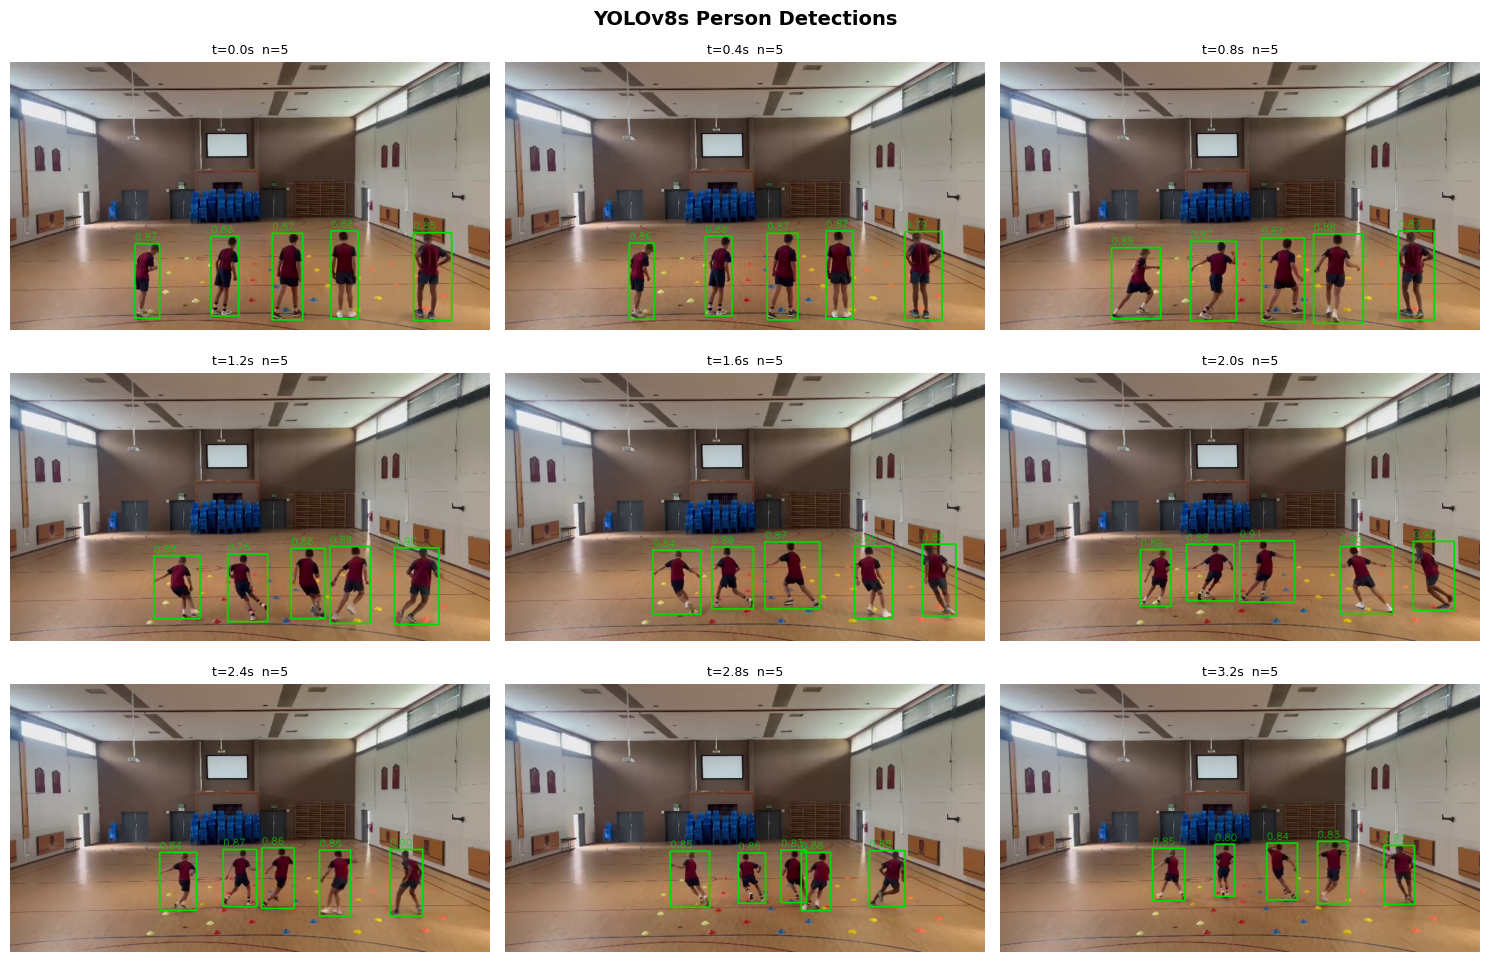

In [4]:
# ── Visualise detections on a 3×3 frame grid ────────────────────────────────
SAMPLE_EVERY = max(1, len(frames) // 9)
sample_idx   = list(range(0, len(frames), SAMPLE_EVERY))[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, fi in zip(axes.flat, sample_idx):
    canvas = frames[fi].copy()
    for det in all_detections[fi]:
        x1, y1, x2, y2 = [int(v) for v in det.bbox]
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 220, 0), 2)
        cv2.putText(canvas, f"{det.confidence:.2f}", (x1, max(y1-6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 220, 0), 1)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f"t={timestamps[fi]:.1f}s  n={len(all_detections[fi])}", fontsize=9)
    ax.axis('off')

plt.suptitle('YOLOv8s Person Detections', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== Detection Summary ===
  Frames processed      : 60
  Total detections      : 300
  Mean detections/frame : 5.00
  Frames with 0 dets    : 0
  Mean confidence       : 0.866
  Min / Max conf        : 0.695 / 0.922


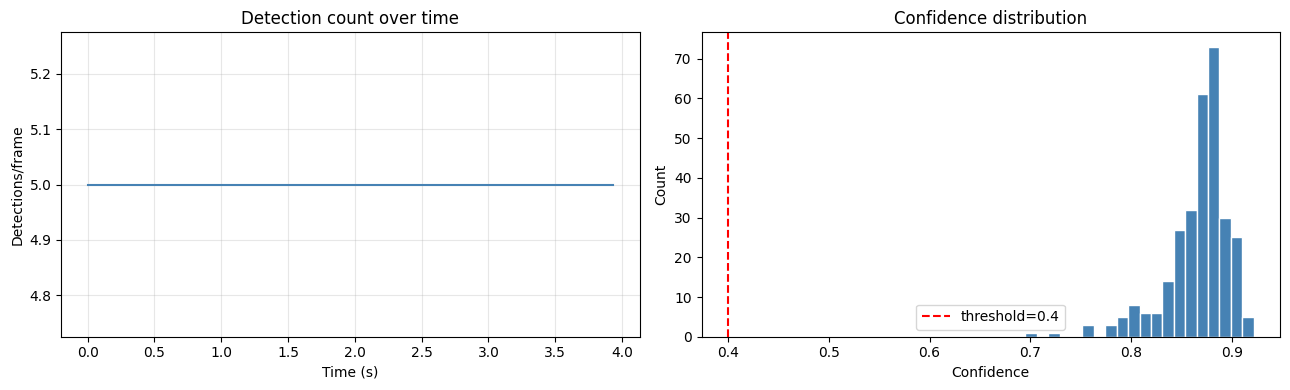

In [5]:
# ── Summary statistics ───────────────────────────────────────────────────────
det_counts = [len(d) for d in all_detections]
all_confs  = [det.confidence for fd in all_detections for det in fd]

print("=== Detection Summary ===")
print(f"  Frames processed      : {len(frames)}")
print(f"  Total detections      : {sum(det_counts)}")
print(f"  Mean detections/frame : {np.mean(det_counts):.2f}")
print(f"  Frames with 0 dets    : {det_counts.count(0)}")
if all_confs:
    print(f"  Mean confidence       : {np.mean(all_confs):.3f}")
    print(f"  Min / Max conf        : {min(all_confs):.3f} / {max(all_confs):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(timestamps[:len(det_counts)], det_counts, color='steelblue')
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Detections/frame')
ax1.set_title('Detection count over time'); ax1.grid(True, alpha=0.3)

if all_confs:
    ax2.hist(all_confs, bins=20, color='steelblue', edgecolor='white')
    ax2.axvline(CONF_THRESHOLD, color='red', linestyle='--', label=f'threshold={CONF_THRESHOLD}')
    ax2.set_xlabel('Confidence'); ax2.set_ylabel('Count')
    ax2.set_title('Confidence distribution'); ax2.legend()

plt.tight_layout(); plt.show()

In [6]:
# ── Save to cache (used by 02_tracking_eval.ipynb) ───────────────────────────
from pipeline.cache import PipelineCache

cache = PipelineCache(job_id=JOB_ID, cache_root=Path('../data/cache'))
cache.save_ingest(frame_indices, timestamps, test_type='explosiveness')
cache.save_detections(all_detections)
print(f"Cached job_id='{JOB_ID}'")
print(cache.summary())

Cached job_id='notebook-eval-detection'
{'job_id': 'notebook-eval-detection', 'cache_dir': '../data/cache/notebook-eval-detection', 'stages_cached': ['ingest', 'detect'], 'test_type': 'explosiveness', 'created_at': '2026-03-04T23:51:18.640201+00:00', 'size_mb': 0.03}
